# Laboratorio 5 · Minería de texto: Clasificación de tweets de desastres

**Curso:** CC3084 · Data Science
**Dataset:** [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data) (Kaggle)

**Objetivo:** explorar el dataset de tweets para entender su estructura, calidad y
patrones de lenguaje, como paso previo a construir un clasificador que determine si
un tweet se refiere a un **desastre real (target = 1)** o **no (target = 0)**.

Este notebook cubre el análisis exploratorio de datos (EDA):

1. Carga y estructura general de los datos
2. Calidad de datos (valores nulos)
3. Balance de la variable objetivo (`target`)
4. Análisis de `keyword` y `location`
5. Características del texto (longitud, palabras, URLs, menciones, hashtags, mayúsculas)
6. Limpieza de texto y palabras más frecuentes
7. Nube de palabras
8. Conclusiones del EDA


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud

sys.path.append(str(Path("..").resolve() / "src"))
from exploratorio import clean_text, get_stopwords, load_data, tokenize_clean

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_DIR = Path("..") / "data" / "raw"


## 1. Carga de datos

Se cargan los tres archivos provistos por Kaggle: `train.csv` (con `target`),
`test.csv` (sin `target`, usado solo para submissions a la competencia) y
`sample_submission.csv` (formato esperado de una submission).

Para este laboratorio el análisis y la futura clasificación se basan en
`train.csv`, que es el único archivo etiquetado.


In [2]:
data = load_data(DATA_DIR)
train = data["train"]
test = data["test"]
sample_submission = data["sample_submission"]

print(f"train: {train.shape[0]} filas, {train.shape[1]} columnas")
print(f"test: {test.shape[0]} filas, {test.shape[1]} columnas")
print(f"sample_submission: {sample_submission.shape[0]} filas, {sample_submission.shape[1]} columnas")


train: 7613 filas, 5 columnas
test: 3263 filas, 4 columnas
sample_submission: 3263 filas, 2 columnas


In [3]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


## 2. Calidad de datos: valores nulos

El dataset advierte que `keyword` y `location` pueden venir en blanco.
Se cuantifica cuánto de cada columna falta.


In [5]:
nulls = train.isna().sum().to_frame("nulos")
nulls["porcentaje"] = (nulls["nulos"] / len(train) * 100).round(2)
nulls


,nulos,porcentaje
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


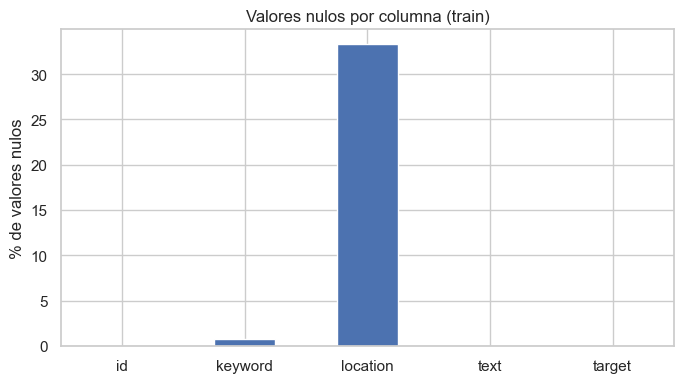

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
nulls["porcentaje"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("% de valores nulos")
ax.set_title("Valores nulos por columna (train)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observación:** `location` tiene una proporción considerable de nulos y,
además, es texto libre escrito por el usuario (no un catálogo controlado), por lo
que contiene mucho ruido (ciudades mal escritas, países, emojis, ubicaciones
inventadas como "Estados Unidos" vs "USA" vs "everywhere"). `keyword` tiene muchos
menos nulos y es más limpio, por lo que es más útil como variable predictiva.


## 3. Balance de la variable objetivo (`target`)

Antes de modelar es clave saber si las clases están balanceadas, ya que eso
condiciona la métrica de evaluación y si se necesita alguna técnica de balanceo.


In [7]:
target_counts = train["target"].value_counts().sort_index()
target_pct = (target_counts / len(train) * 100).round(2)

resumen_target = pd.DataFrame({"conteo": target_counts, "porcentaje": target_pct})
resumen_target.index = ["0 · No desastre", "1 · Desastre real"]
resumen_target


,conteo,porcentaje
0 · No desastre,4342,57.03
1 · Desastre real,3271,42.97


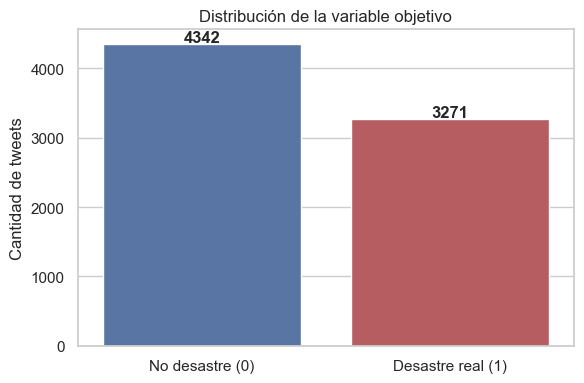

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="target", data=train, hue="target", palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No desastre (0)", "Desastre real (1)"])
ax.set_xlabel("")
ax.set_ylabel("Cantidad de tweets")
ax.set_title("Distribución de la variable objetivo")
for i, v in enumerate(target_counts):
    ax.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


**Observación:** las clases están moderadamente desbalanceadas
(~57% no-desastre vs ~43% desastre real), pero no de forma extrema. No es
necesario un remuestreo agresivo; conviene reportar F1-score además de accuracy
al momento de clasificar.


## 4. Análisis de `keyword`

Se revisan las keywords más frecuentes y cuáles están más asociadas a tweets de
desastre real vs. no real.


In [9]:
print(f"Keywords únicas: {train['keyword'].nunique()}")
train["keyword"].value_counts().head(15)


Keywords únicas: 221


keyword
fatalities     45
deluge         42
armageddon     42
damage         41
body%20bags    41
harm           41
sinking        41
evacuate       40
outbreak       40
fear           40
siren          40
windstorm      40
collided       40
twister        40
hellfire       39
Name: count, dtype: int64

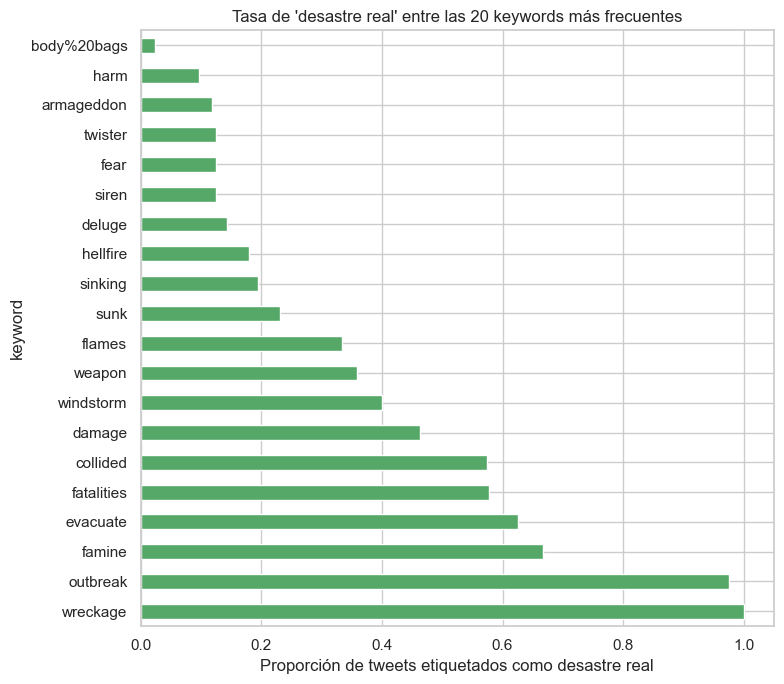

In [10]:
top_keywords = train["keyword"].value_counts().head(20).index
subset = train[train["keyword"].isin(top_keywords)]

tasa_por_keyword = (
    subset.groupby("keyword")["target"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 7))
tasa_por_keyword.plot(kind="barh", ax=ax, color="#55A868")
ax.set_xlabel("Proporción de tweets etiquetados como desastre real")
ax.set_title("Tasa de 'desastre real' entre las 20 keywords más frecuentes")
plt.tight_layout()
plt.show()


**Observación:** algunas keywords son casi puramente predictivas
(p. ej. términos asociados a derrumbes o accidentes suelen tener tasas cercanas
a 1), mientras que otras como *body bags* o *harm* aparecen con más frecuencia
en tweets no relacionados a un desastre real (uso figurado/coloquial). Esto
sugiere que `keyword` puede ser una variable útil para el modelo, aunque no
suficiente por sí sola.


## 5. Análisis de `location`

`location` es texto libre y muy ruidoso. Se revisan los valores más comunes tal
como vienen, sin intentar normalizarlos (una normalización completa de
geolocalización queda fuera del alcance de este EDA).


In [11]:
train["location"].value_counts().head(15)


location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Washington, DC      21
Kenya               20
Worldwide           19
Chicago, IL         18
Australia           18
Name: count, dtype: int64

**Observación:** aparecen ubicaciones reales (`New York`, `USA`,
`London`), pero también ubicaciones no geográficas o ambiguas (`worldwide`,
`Everywhere`), duplicados por formato (`USA` vs `United States`) y valores muy
dispersos (alta cardinalidad, cola larga). Por esta razón `location` no se usa
como variable predictiva directa en este laboratorio.


## 6. Características del texto

Se calculan métricas simples sobre el texto crudo de cada tweet y se comparan
entre las dos clases: longitud en caracteres, cantidad de palabras, y presencia
de URLs, menciones (`@`), hashtags (`#`) y palabras en mayúsculas (posible señal
de urgencia/alarma).


In [12]:
train["n_caracteres"] = train["text"].str.len()
train["n_palabras"] = train["text"].str.split().str.len()
train["tiene_url"] = train["text"].str.contains(r"https?://", regex=True)
train["tiene_mencion"] = train["text"].str.contains(r"@\w+", regex=True)
train["tiene_hashtag"] = train["text"].str.contains(r"#\w+", regex=True)
train["n_mayusculas"] = train["text"].str.findall(r"\b[A-Z]{2,}\b").str.len()

train[["n_caracteres", "n_palabras", "tiene_url", "tiene_mencion", "tiene_hashtag", "n_mayusculas"]].describe()


,n_caracteres,n_palabras,n_mayusculas
count,7613.000000,7613.000000,7613.000000
mean,101.037436,14.903586,0.638907
std,33.781325,5.732604,1.870279
min,7.000000,1.000000,0.000000
25%,78.000000,11.000000,0.000000
50%,107.000000,15.000000,0.000000
75%,133.000000,19.000000,1.000000
max,157.000000,31.000000,23.000000


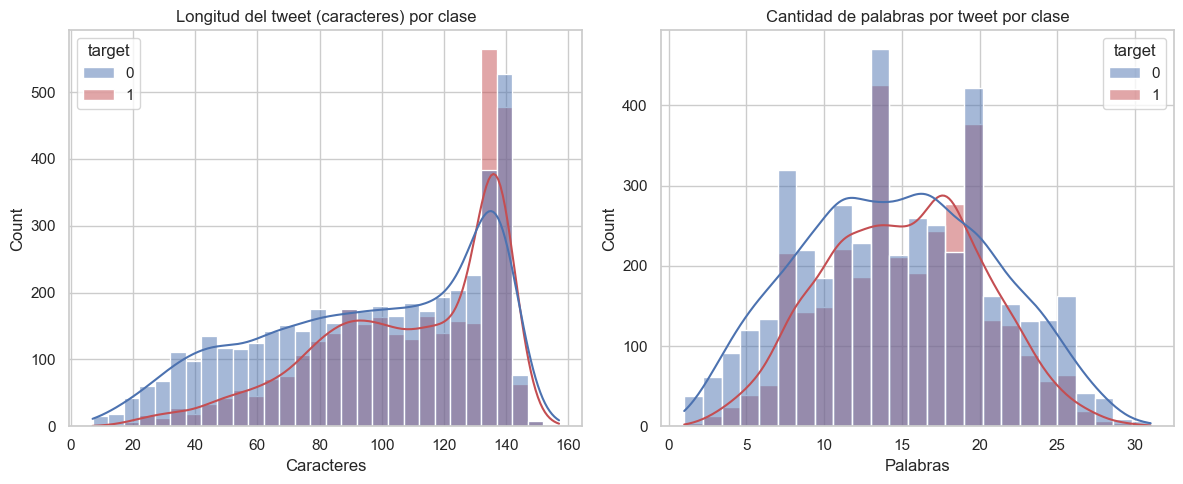

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=train, x="n_caracteres", hue="target", bins=30, kde=True,
             palette=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Longitud del tweet (caracteres) por clase")
axes[0].set_xlabel("Caracteres")

sns.histplot(data=train, x="n_palabras", hue="target", bins=25, kde=True,
             palette=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_title("Cantidad de palabras por tweet por clase")
axes[1].set_xlabel("Palabras")

plt.tight_layout()
plt.show()


In [14]:
features_binarias = ["tiene_url", "tiene_mencion", "tiene_hashtag"]
tabla = train.groupby("target")[features_binarias].mean().rename(
    index={0: "No desastre", 1: "Desastre real"}
) * 100
tabla = tabla.round(1)
tabla


,tiene_url,tiene_mencion,tiene_hashtag
target,,,
No desastre,41.4,30.9,20.4
Desastre real,66.4,20.4,26.2


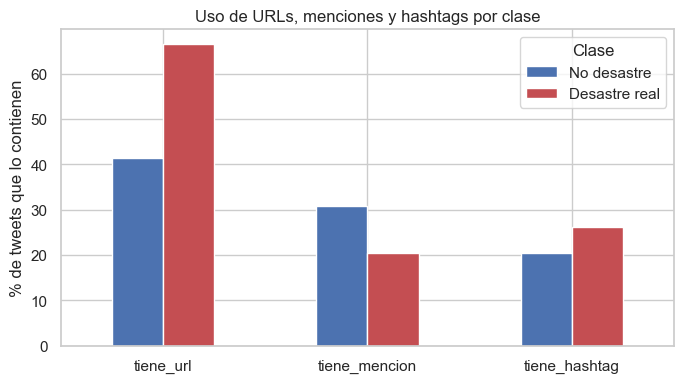

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
tabla.T.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("% de tweets que lo contienen")
ax.set_title("Uso de URLs, menciones y hashtags por clase")
plt.xticks(rotation=0)
plt.legend(title="Clase")
plt.tight_layout()
plt.show()


**Observación:** los tweets de desastre real tienden a ser un poco más
largos y a incluir URLs con más frecuencia (comúnmente enlazando a noticias o
imágenes), mientras que las menciones (`@usuario`) son más comunes en tweets
que no son sobre desastres reales (conversación entre usuarios, uso figurado
del lenguaje). Estas diferencias son señales útiles, aunque moderadas.


## 7. Limpieza de texto y palabras más frecuentes

Se limpia el texto (minúsculas, sin URLs, menciones, símbolos `#`, HTML
entities y puntuación) y se remueven *stopwords* en inglés más ruido propio de
Twitter (`rt`, `amp`, etc.), usando las funciones de `src/exploratorio.py` para
que el proceso sea reproducible.


In [16]:
stop_words = get_stopwords()

train["texto_limpio"] = train["text"].apply(clean_text)
train["tokens"] = train["text"].apply(lambda t: tokenize_clean(t, stop_words))

train[["text", "texto_limpio", "tokens"]].head(5)


,text,texto_limpio,tokens
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,"[deeds, reason, earthquake, may, allah, forgive]"
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,"[forest, fire, near, ronge, sask, canada]"
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...,"[residents, asked, shelter, place, notified, o..."
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...,"[people, receive, wildfires, evacuation, order..."
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,"[got, sent, photo, ruby, alaska, smoke, wildfi..."


In [17]:
from collections import Counter

def top_palabras(df, n=20):
    contador = Counter(word for tokens in df["tokens"] for word in tokens)
    return pd.DataFrame(contador.most_common(n), columns=["palabra", "frecuencia"])

top_general = top_palabras(train, 20)
top_general


,palabra,frecuencia
0,fire,254
1,news,209
2,people,199
3,video,165
4,disaster,158
5,emergency,158
6,police,143
7,would,137
8,body,131
9,time,130


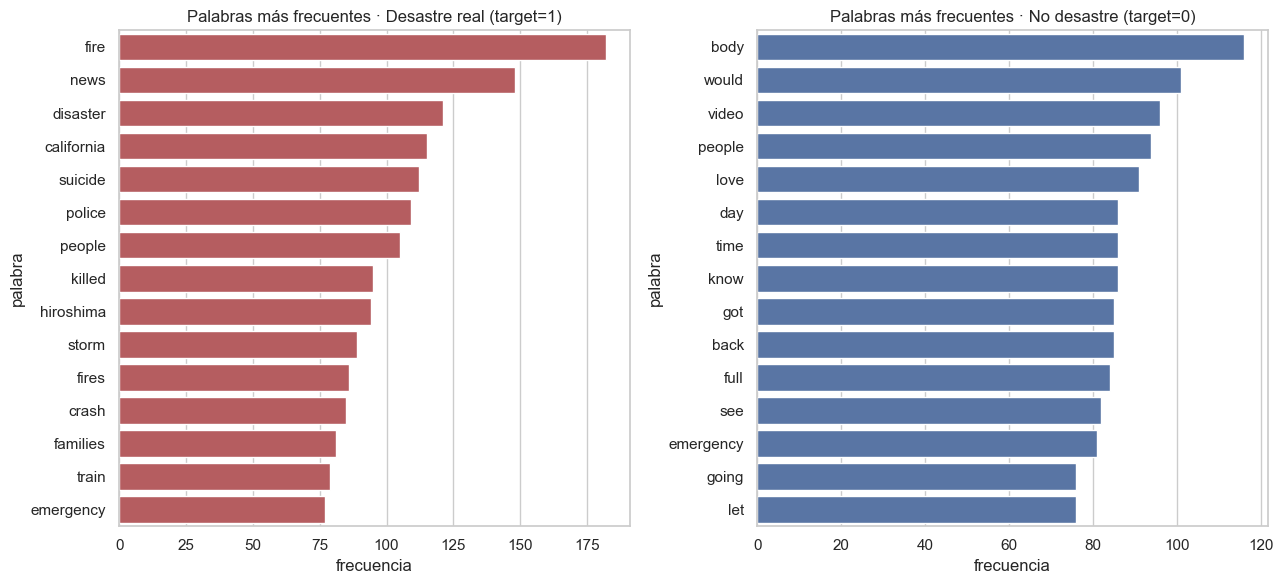

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=False)

top_1 = top_palabras(train[train["target"] == 1], 15)
top_0 = top_palabras(train[train["target"] == 0], 15)

sns.barplot(data=top_1, y="palabra", x="frecuencia", ax=axes[0], color="#C44E52")
axes[0].set_title("Palabras más frecuentes · Desastre real (target=1)")

sns.barplot(data=top_0, y="palabra", x="frecuencia", ax=axes[1], color="#4C72B0")
axes[1].set_title("Palabras más frecuentes · No desastre (target=0)")

plt.tight_layout()
plt.show()


**Observación:** en los tweets de desastre real predominan sustantivos
concretos ligados a eventos (`fire`, `disaster`, `california`, `police`,
`killed`, `storm`, `crash`, `emergency`), mientras que en los tweets no
relacionados predominan palabras de uso más coloquial o genérico (`would`,
`video`, `love`, `day`, `time`, `lol`, `full`, usados en expresiones
cotidianas). Vale la pena notar que algunas palabras (`body`, `fire`,
`emergency`) aparecen en ambas clases con frecuencia alta: por sí solas no
bastan para distinguir la clase, lo que confirma que hace falta el contexto
completo del texto (no solo palabras sueltas) para clasificar bien. Esta
separación léxica parcial es justamente lo que un clasificador de texto
(p. ej. TF-IDF + un modelo lineal) puede aprovechar.


## 8. Nube de palabras

Se genera una nube de palabras para detectar visualmente los términos más
repetidos, tanto en general como separado por clase.


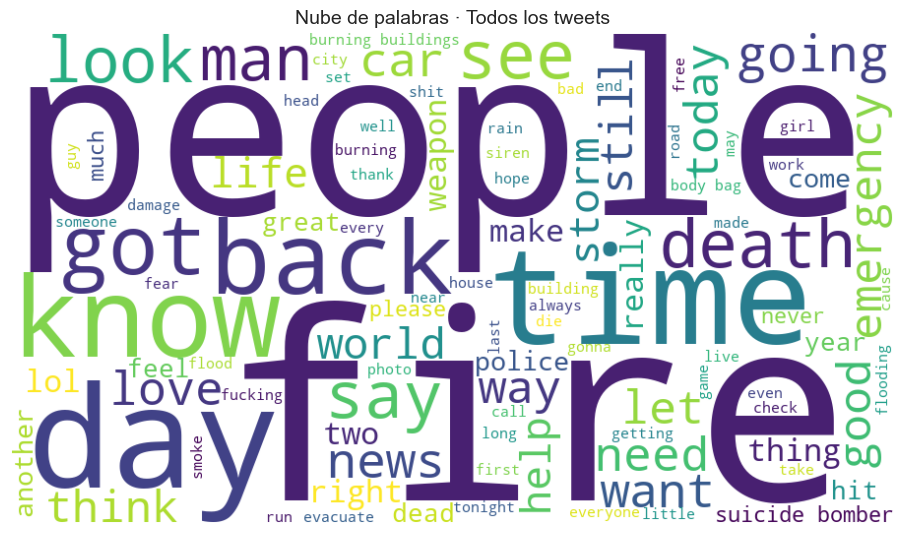

In [19]:
def generar_wordcloud(tokens_series, titulo, colormap="viridis"):
    texto = " ".join(word for tokens in tokens_series for word in tokens)
    wc = WordCloud(
        width=900, height=500, background_color="white",
        colormap=colormap, max_words=100, random_state=42,
    ).generate(texto)

    plt.figure(figsize=(10, 5.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titulo, fontsize=14)
    plt.tight_layout()
    plt.show()

generar_wordcloud(train["tokens"], "Nube de palabras · Todos los tweets", colormap="viridis")


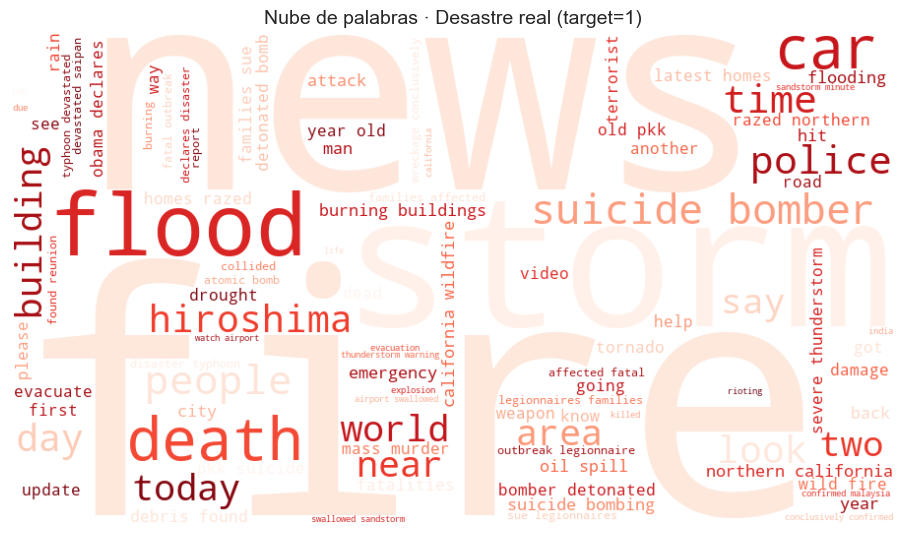

In [20]:
generar_wordcloud(train.loc[train["target"] == 1, "tokens"],
                   "Nube de palabras · Desastre real (target=1)", colormap="Reds")


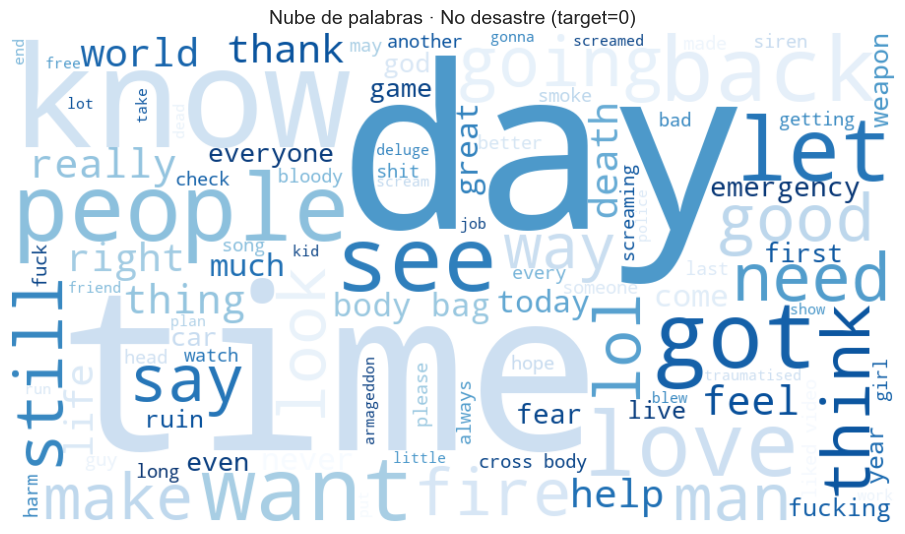

In [21]:
generar_wordcloud(train.loc[train["target"] == 0, "tokens"],
                   "Nube de palabras · No desastre (target=0)", colormap="Blues")


## 9. Conclusiones del EDA

- **Balance de clases:** moderadamente desbalanceado (57% / 43%), manejable sin
  técnicas especiales de balanceo; conviene reportar F1-score.
- **Calidad de datos:** `location` es demasiado ruidosa y de alta cardinalidad
  para usarse directamente; `keyword` es más confiable y muestra asociación
  clara con `target` para varias palabras clave.
- **Señales en el texto:** los tweets de desastre real son en promedio más
  largos, usan más URLs (enlaces a noticias) y menos menciones que los tweets
  no relacionados.
- **Vocabulario:** existe una separación léxica clara entre ambas clases
  (palabras de eventos concretos vs. lenguaje coloquial/figurado), visible
  tanto en los conteos de frecuencia como en las nubes de palabras.
- **Implicación para el modelado:** estas señales (texto limpio + longitud +
  presencia de URL + keyword) son un buen punto de partida para un
  clasificador basado en TF-IDF sobre `texto_limpio`, complementado con las
  features numéricas/binarias calculadas en la sección 6.
